# Resource Selection Function

In [1]:
import geemap, ee
import pandas as pd, geopandas as gpd
import xarray
import hvplot, hvplot.pandas, hvplot.xarray
import matplotlib.pyplot as plt, seaborn as sns
import numpy as np
import xarray as xr
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from scipy.stats import spearmanr
import itertools
ee.Initialize(project = "test-with-greta")

In [2]:
from dask.distributed import default_client
try:
    default_client().shutdown()
except Exception:
    pass

In [3]:
from dask.distributed import Client, LocalCluster
import os, dask

cluster = LocalCluster(
    n_workers=max(2, os.cpu_count()//2),
    threads_per_worker=1,
    processes=True,
    memory_limit="auto",
    dashboard_address=":8787",
    local_directory=r"dask-tmp",
)

dask.config.set({
    "distributed.worker.memory.target": 0.75,
    "distributed.worker.memory.spill": 0.85,
    "distributed.worker.memory.pause": 0.92,
    "distributed.worker.memory.terminate": 0.98,
})

def init_ee():
    import ee
    ee.Initialize(project = "test-with-greta")
    ee.data.setCloudApiUserProject("test-with-greta")
    return ee.Number(1).getInfo()

client = Client(cluster)
client.run(init_ee)

{'tcp://127.0.0.1:35883': 1,
 'tcp://127.0.0.1:36883': 1,
 'tcp://127.0.0.1:38853': 1,
 'tcp://127.0.0.1:45669': 1}

## 1. Preparation

### 1.1 Fetch presence data

In [4]:
reloc = pd.read_csv("data/NPL38.csv")[["Timestamp", "ID", "Latitude", "Longitude"]]
reloc = gpd.GeoDataFrame(reloc, geometry = gpd.points_from_xy(reloc["Longitude"], reloc["Latitude"]), crs = 4326).to_crs(29333)
reloc["Timestamp"] = pd.to_datetime(reloc["Timestamp"])
reloc.head()

,Timestamp,ID,Latitude,Longitude,geometry
0,2022-03-03 19:15:02,NPL38,-19.88068,13.93503,POINT (388575.212 7801620.974)
1,2022-03-04 19:07:04,NPL38,-19.66205,14.09336,POINT (405022.246 7825913.386)
2,2022-03-05 19:08:58,NPL38,-19.65892,14.09013,POINT (404681.771 7826257.968)
3,2022-03-06 19:09:40,NPL38,-19.64331,14.06755,POINT (402305.037 7827972.683)
4,2022-03-07 19:11:10,NPL38,-19.65625,14.04916,POINT (400384.834 7826529.986)


### 1.2 For multiple individuals

In [5]:
from glob import glob
rows = []
for csv in glob("data/*.csv"):
    rows.append(pd.read_csv(csv)[["Timestamp", "ID", "Latitude", "Longitude"]])
reloc = pd.concat(rows)

In [6]:
reloc = gpd.GeoDataFrame(reloc, geometry = gpd.points_from_xy(reloc["Longitude"], reloc["Latitude"]), crs = 4326).to_crs(29333)
reloc["Timestamp"] = pd.to_datetime(reloc["Timestamp"])

In [7]:
reloc.groupby("ID")["Timestamp"].min().sort_values()

ID
NPL38   2022-03-03 19:15:02
NPL35   2022-06-21 20:26:50
NPL28   2022-10-08 00:00:21
NPL39   2024-05-04 00:00:19
NPL34   2024-05-19 20:45:09
NPL36   2024-05-19 23:45:10
NPL37   2024-05-24 20:15:09
NPL40   2024-11-06 14:07:49
Name: Timestamp, dtype: datetime64[ns]

In [8]:
# Let's set 2025 as a cut-of to ensure all lions have datapoints
reloc = reloc[reloc["Timestamp"] >= pd.to_datetime("2025-01-01")]

### 1.2 Fetch environmental layers

In [5]:
# Define aoi 
aoi = gpd.GeoDataFrame(geometry = [reloc.union_all().envelope.buffer(1)], crs = reloc.crs)
aoi_ee = geemap.geopandas_to_ee(aoi)

In [6]:
# Fetch raw EO 
def mask_s2_sr(img):
    qa = img.select("QA60")
    cloud  = 1 << 10
    cirrus = 1 << 11
    mask = qa.bitwiseAnd(cloud).eq(0).And(qa.bitwiseAnd(cirrus).eq(0))
    return img.updateMask(mask).divide(10000).copyProperties(img, ["system:time_start"])

s2 = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
      .filterBounds(aoi_ee)
      .filterDate("2024-01-01", "2024-12-31")
      .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 30))
      .map(mask_s2_sr))

In [7]:
# Calculate relevant indices
# NDVI
ndvi = (s2.map(lambda img: img.normalizedDifference(["B8", "B4"]).rename("ndvi"))
          .median()
          .clip(aoi_ee))

# NDWI (McFeeters): (Green - NIR) / (Green + NIR)
ndwi = (s2.map(lambda img: img.normalizedDifference(["B3", "B8"]).rename("ndwi"))
          .median()
          .clip(aoi_ee))

# --- 3) Topography ---
altitude = ee.Image("USGS/SRTMGL1_003").select("elevation").clip(aoi_ee)
slope = ee.Terrain.slope(altitude).rename("slope")

# --- 4) Distance to water (JRC Global Surface Water) ---
gsw = ee.Image("JRC/GSW1_4/GlobalSurfaceWater").select("occurrence").clip(aoi_ee)
water = gsw.gte(10).selfMask() 

# Distance transform gives pixel distance in pixels; multiply by nominal scale to get meters
scale_m = 30 
dist_to_water = (water.fastDistanceTransform(256).sqrt()
                 .multiply(scale_m)
                 .rename("dist2water")
                 .clip(aoi_ee))

In [8]:
# Stack into multiband image
predictors_img = (ndvi
                  .addBands([ndwi, slope, dist_to_water])
                  .toFloat()
                  .clip(aoi_ee))

Map = geemap.Map()

for b in predictors_img.bandNames().getInfo():
    Map.addLayer(predictors_img.select(b), {}, b) 

Map

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI(childr…

In [9]:
# Transform into xarray
ds = geemap.ee_to_xarray(predictors_img, crs = "EPSG:29333", scale = 30, geometry = aoi_ee.geometry()).chunk()
ds = geemap.ee_to_xarray(
    predictors_img, crs="EPSG:29333", scale=30, geometry=aoi_ee.geometry()
)

ds0 = (ds.isel(time=0, drop=True)
         .rename({"X": "x", "Y": "y"})
         .chunk({"y": 1024, "x": 1024}))   

env = (
    ds0.to_array(dim="band")
       .transpose("band", "y", "x")
       .chunk({"band": -1, "y": 1024, "x": 1024})   # <-- add this
       .rio.write_crs("EPSG:29333")
)

In [10]:
env = env.persist()

In [ ]:
env.to_dataset(name="env").to_zarr("env_29333.zarr", mode="w")

In [6]:
env = xr.open_zarr("env_29333.zarr")["env"]

## 2. Calculate the RSF

### 2.1 Define the sampling scheme

In [7]:
def get_availability_domain(used: pd.DataFrame, estimator = "MCP", thres = 0.95):

    if estimator == "MCP":
        centroid = used.geometry.union_all().centroid
        tmp = used.copy()
        tmp["dist_to_centroid"] = tmp.geometry.distance(centroid)
        points_within_95 = tmp[tmp["dist_to_centroid"] <= np.quantile(tmp["dist_to_centroid"], thres)]
        mcp_95 = points_within_95.geometry.union_all().convex_hull
        mcp_95 = gpd.GeoDataFrame(geometry = [mcp_95], crs = used.crs)
        domain = mcp_95

    return domain

In [8]:
def get_sampling_points(domain, n, df = None, seed: int = 42) -> pd.DataFrame:

    available = gpd.GeoDataFrame(geometry = domain.sample_points(n, rng = seed).explode(), crs = domain.crs)
    
    if df is not None:
        samples = df[["Timestamp", "geometry"]].copy() 
        samples["used"] = True
        samples = pd.concat([samples, available])
        samples["used"] = samples["used"].fillna(False)
    else:
        samples = available
        samples["Timestamp"] = None
        samples["used"] = False
        
    return samples

In [9]:
domain = get_availability_domain(reloc)

In [10]:
samples = get_sampling_points(domain, len(reloc) * 10, reloc)

/tmp/ipykernel_1740668/440494965.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  samples["used"] = samples["used"].fillna(False)


In [11]:
samples

,Timestamp,geometry,used
0,2022-03-03 19:15:02,POINT (388575.212 7801620.974),True
1,2022-03-04 19:07:04,POINT (405022.246 7825913.386),True
2,2022-03-05 19:08:58,POINT (404681.771 7826257.968),True
3,2022-03-06 19:09:40,POINT (402305.037 7827972.683),True
4,2022-03-07 19:11:10,POINT (400384.834 7826529.986),True
...,...,...,...
0,NaT,POINT (434151.343 7834174.163),False
0,NaT,POINT (434171.643 7834303.905),False
0,NaT,POINT (434171.815 7834648.759),False
0,NaT,POINT (434184.97 7834611.194),False


### 2.2 Extract values from the environmental covariates

In [12]:
def sample_env_layer(samples: gpd.GeoDataFrame, env: xarray.DataArray, chunk_size_points=20_000):
    xs = xr.DataArray(samples.geometry.x.to_numpy(), dims="points", name="x")
    ys = xr.DataArray(samples.geometry.y.to_numpy(), dims="points", name="y")

    sampled = env.sel(x=xs, y=ys, method="nearest").chunk({"points": chunk_size_points})

    arr = sampled.data
    arr = arr.compute() if hasattr(arr, "compute") else np.asarray(arr)
    arr = np.asarray(arr, dtype="float32")

    bands = sampled["band"].to_numpy().tolist()
    df = pd.DataFrame(arr.T, columns=bands)
    df["x"] = xs.to_numpy()
    df["y"] = ys.to_numpy()
    df["used"] = samples["used"].to_numpy()
    df["Timestamp"] = samples["Timestamp"].to_numpy()
    return df

In [13]:
sampled = sample_env_layer(samples, env)

In [14]:
sampled.head()

,ndvi,ndwi,slope,dist2water,x,y,used,Timestamp
0,0.111995,-0.275852,3.097749,13548.446289,388575.211625,7.801621e+06,True,2022-03-03 19:15:02
1,0.163308,-0.377278,20.028107,11890.033203,405022.246226,7.825913e+06,True,2022-03-04 19:07:04
2,0.149278,-0.345938,14.111135,11933.251953,404681.770993,7.826258e+06,True,2022-03-05 19:08:58
3,0.167543,-0.342025,3.832719,11006.566406,402305.037319,7.827973e+06,True,2022-03-06 19:09:40
4,0.123805,-0.339046,8.841487,8673.943359,400384.833511,7.826530e+06,True,2022-03-07 19:11:10


### 2.3 Fit logistic regression

In [15]:
from dataclasses import dataclass
from typing import List, Tuple, Optional

@dataclass(frozen=True)
class FeatureSpec:
    linear: List[str]                                          
    quadratic: Optional[List[str]] = None      
    interactions: Optional[List[Tuple[str, str]]] = None  
    add_const: bool = True

In [16]:
def build_design_matrix(df: pd.DataFrame, spec: FeatureSpec,
    scaler: StandardScaler | None = None, fit_scaler: bool = False) -> tuple[pd.DataFrame, StandardScaler]:

    # We scale linear terms
    Xc = df[spec.linear].copy()
    if scaler is None:
        scaler = StandardScaler()

    X = scaler.fit_transform(Xc) if fit_scaler else scaler.transform(Xc)
    X = pd.DataFrame(X, columns=spec.linear, index=df.index)

    # Quadratic terms
    if spec.quadratic:
        for v in spec.quadratic:
            X[f"{v}__sq"] = X[v] ** 2

    # Interactions
    if spec.interactions:
        for a, b in spec.interactions:
            X[f"{a}__x__{b}"] = X[a] * X[b]

    # add intercept
    if spec.add_const:
        X = sm.add_constant(X, has_constant="add")

    return X, scaler

In [17]:
spec = FeatureSpec(linear = ["ndvi", "slope", "dist2water"], interactions = [("ndvi", "slope")])

In [18]:
des, scaler = build_design_matrix(sampled, spec, fit_scaler = True)
des.head()

,const,ndvi,slope,dist2water,ndvi__x__slope
0,1.0,-0.405022,-0.773421,0.246235,0.313253
1,1.0,1.334611,1.653478,0.172872,2.206750
2,1.0,0.858944,0.805304,0.174784,0.691711
3,1.0,1.478201,-0.668066,0.133790,-0.987536
4,1.0,-0.004639,0.049921,0.030602,-0.000232


In [19]:
def fit_rsf(df, spec: FeatureSpec):
    y = df["used"].astype(int)
    Xz, scaler = build_design_matrix(df, spec, scaler=None, fit_scaler=True)
    m = sm.Logit(y, Xz).fit(disp=False)
    return m, scaler, spec

In [20]:
m, scaler, spec = fit_rsf(sampled, spec)

In [21]:
print(m.summary())

                           Logit Regression Results                           
Dep. Variable:                   used   No. Observations:               146608
Model:                          Logit   Df Residuals:                   146603
Method:                           MLE   Df Model:                            4
Date:                 Mi, 07 Jan 2026   Pseudo R-squ.:                 0.05076
Time:                        11:16:50   Log-Likelihood:                -42395.
converged:                       True   LL-Null:                       -44662.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -2.4191      0.010   -240.324      0.000      -2.439      -2.399
ndvi               0.2963      0.011     27.917      0.000       0.276       0.317
slope             -0.2620      0.012

In [24]:
def predict_rsf_points(df, m, scaler, spec):
    Xz, _ = build_design_matrix(df, spec, scaler=scaler, fit_scaler=False)
    eta = m.predict(Xz, which = "linear")
    out = df.copy()
    out["rsf_pred"] = np.exp(eta)
    return out

In [25]:
pred = predict_rsf_points(sampled, m, scaler, spec)
pred.head()

,ndvi,ndwi,slope,dist2water,x,y,used,Timestamp,rsf_pred
0,0.111995,-0.275852,3.097749,13548.446289,388575.211625,7.801621e+06,True,2022-03-03 19:15:02,0.140815
1,0.163308,-0.377278,20.028107,11890.033203,405022.246226,7.825913e+06,True,2022-03-04 19:07:04,0.103108
2,0.149278,-0.345938,14.111135,11933.251953,404681.770993,7.826258e+06,True,2022-03-05 19:08:58,0.119169
3,0.167543,-0.342025,3.832719,11006.566406,402305.037319,7.827973e+06,True,2022-03-06 19:09:40,0.211107
4,0.123805,-0.339046,8.841487,8673.943359,400384.833511,7.826530e+06,True,2022-03-07 19:11:10,0.092067


In [26]:
def partial_dependence(m, interaction, predictor, influencer, predictor_z_range = (-3, 3), influencer_z_range = (-1, 1), evaluate_at_n = 300):

    # Build list on which to evaluate the rsf function
    predictor_z = np.linspace(predictor_z_range[0], predictor_z_range[1], evaluate_at_n)
    fig, ax = plt.subplots(figsize = (12, 8))

    # Loop through the levels of the covariate influencing the target (constraint)
    for level in range(influencer_z_range[0], influencer_z_range[1]+1):
        # Calculate the function: We only need the three terms
        eta = (m.params["const"] + 
               m.params[predictor] * predictor_z + 
               m.params[influencer] * level + 
               m.params[interaction] * predictor_z * level)
        
        eta0 = m.params["const"]  + m.params[influencer] * level 
        rsf = np.exp(eta - eta0)
        ax.plot(predictor_z, rsf, label = f"Evaluated at {influencer} z = {level}")

    ax.set_xlabel(f"{predictor} (z-score)")
    ax.set_ylabel("RSF (relative intensity)")
    ax.set_title(f"Partial dependence: {predictor} at varying {influencer} (normalized at {predictor}_z=0)")
    plt.legend()
    plt.tight_layout()
    plt.show()


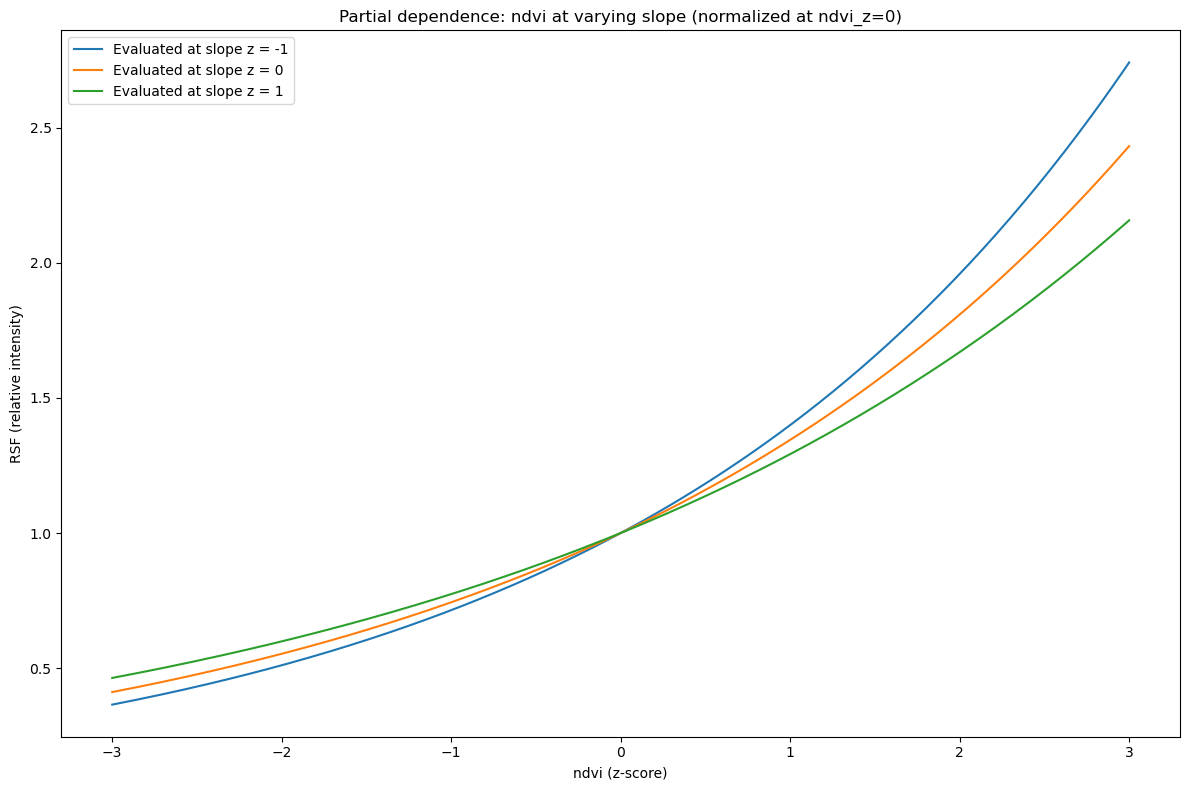

In [27]:
partial_dependence(m, "ndvi__x__slope", "ndvi", "slope")

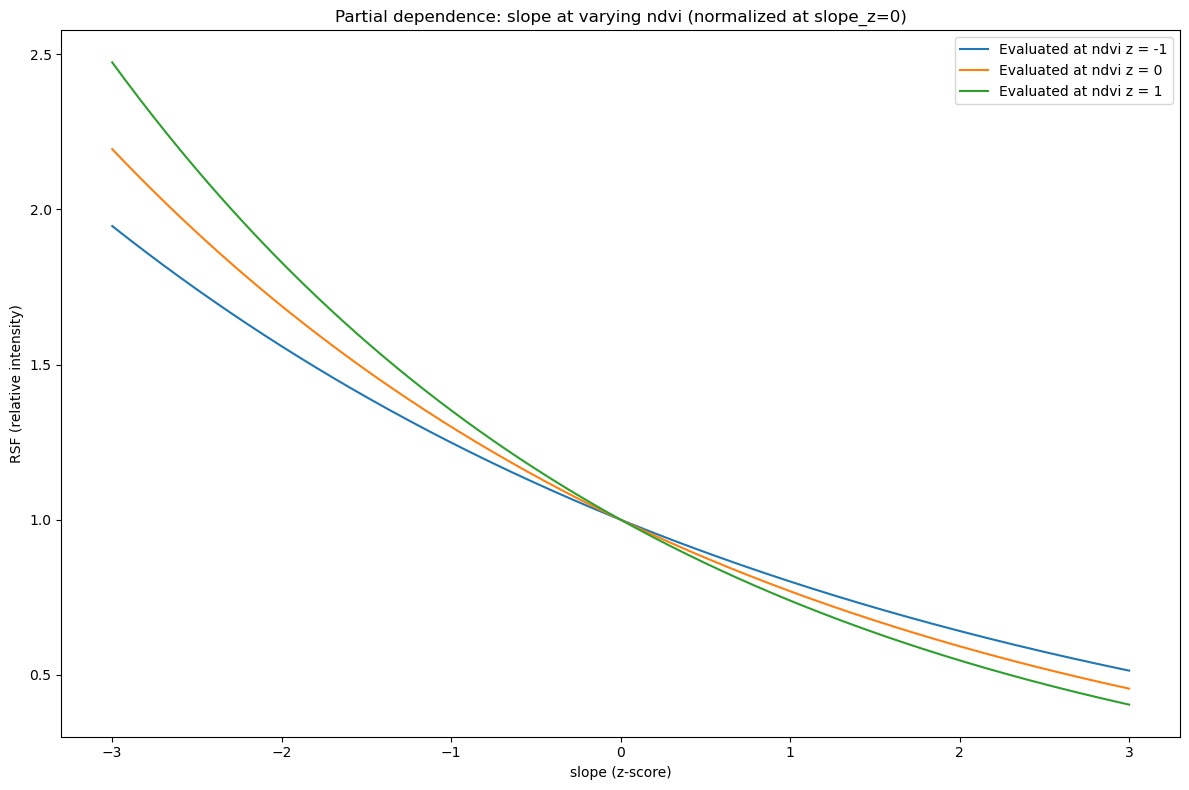

In [28]:
partial_dependence(m, "ndvi__x__slope", "slope", "ndvi")

### 2.4 Get RSF surface

In [29]:
def get_rsf_surface(env, res, scaler, spec: FeatureSpec):

    base = list(spec.linear)
    env = env.sel(band = base)
    coef = res.params

    eta = xr.zeros_like(env.sel(band=base[0])) + float(coef.get("const", 0.0))

    z = {}
    for i, v in enumerate(base):
        layer = env.sel(band=v)
        z[v] = (layer - float(scaler.mean_[i])) / float(scaler.scale_[i])

        # linear term
        if v in coef.index:
            eta = eta + z[v] * float(coef[v])

    # quadratic terms (on z-scored base)
    if spec.quadratic:
        for v in spec.quadratic:
            name = f"{v}__sq"
            if name in coef.index:
                eta = eta + (z[v] ** 2) * float(coef[name])

    # interactions (on z-scored base)
    if spec.interactions:
        for a, b in spec.interactions:
            name = f"{a}__x__{b}"
            if name in coef.index:
                eta = eta + (z[a] * z[b]) * float(coef[name])

    rsf = np.exp(eta).rename("rsf").expand_dims(band=["rsf"])
    return rsf

In [30]:
rsf = get_rsf_surface(env, m, scaler, spec)

In [ ]:
# rsf = rsf.compute()
# 

In [ ]:
rsf = rsf.compute()

In [ ]:
rsf.rio.to_raster("rsf.tif", compress="LZW")

In [ ]:
rsf2d = rsf.sel(band="rsf").squeeze(drop=True).astype("float32")
mu = rsf2d.mean(dim=("y","x"), skipna=True)
sd = rsf2d.std(dim=("y","x"), skipna=True)
rsf_z = ((rsf2d - mu) / (sd + 1e-12)).astype("float32").rename("rsf_z")

In [ ]:
# Normalization
rsf2d = rsf.sel(band="rsf").squeeze(drop=True).astype("float32")
dx, dy = rsf2d.rio.resolution()
pixel_area = abs(float(dx * dy))
Z = (rsf2d * pixel_area).sum(dim=("y", "x"), skipna=True)  
p = (rsf2d / Z).rename("p")  

In [ ]:
lo = float(rsf_z.quantile(0.01, skipna=True))
hi = float(rsf_z.quantile(0.99, skipna=True))
rsf_z.clip(lo, hi).rio.reproject("EPSG:4326").hvplot(x = "x", y = "y", geo = True, tiles = "EsriImagery", cmap = "Greens", alpha = 0.8, width = 1200, height = 800)

### 2.5 Evaluate Using Boyce Index

In [31]:
def fixed_width_Boyce(pred, rsf, domain, n_bg_points=100_000, n_bins=20, seed=42):
    bg_points = get_sampling_points(domain, n_bg_points, seed=seed)
    bg_samples = sample_env_layer(bg_points, rsf)
    bg = np.log(bg_samples["rsf"].to_numpy(dtype=float))

    used = np.log(pred.loc[pred["used"] == True, "rsf_pred"].to_numpy(dtype=float))

    q_edges = np.linspace(0, 1, n_bins + 1)
    edges = np.quantile(bg, q_edges)
    edges[-1] = np.nextafter(edges[-1], np.inf)
    edges = np.unique(edges)

    u_cnt, _ = np.histogram(used, bins=edges)
    b_cnt, _ = np.histogram(bg, bins=edges)

    u_prop = u_cnt / used.size
    b_prop = b_cnt / bg.size
    pe = np.divide(u_prop, b_prop, out=np.full_like(u_prop, np.nan, dtype=float), where=(b_prop > 0))

    # midpoints in prediction-space (log RSF)
    mids = 0.5 * (edges[:-1] + edges[1:])

    # midpoints in quantile-space (0..1), matched to the same bins
    # if edges got uniqued (ties), rebuild q mids based on len(pe)
    q_mids = (np.arange(len(pe)) + 0.5) / len(pe)

    chart = pd.DataFrame({"q_mid": q_mids, "rsf_mid": mids, "pe": pe})
    B, _ = spearmanr(mids, pe, nan_policy="omit")
    return B, chart

In [ ]:
B, boyce = fixed_width_Boyce(pred, rsf)

In [ ]:
print(boyce)

In [ ]:
fig, ax = plt.subplots(figsize = (12, 8))
sns.lineplot(boyce, x = "rsf_mid", y = "pe", ax = ax)
ax.set_xlabel("Midpoints of the RSF-bins")
ax.set_ylabel("F-Ratio: Predicted to Expected")
plt.axhline(y = 1, linestyle = "--", color = "black")
plt.title(f"Fixed-width Boyce: {B:.2f}")
plt.show()

In [ ]:
def sliding_window_Boyce(pred: gpd.GeoDataFrame, rsf: xarray.DataArray, window_frac: float = 0.1, step_frac: float = 0.02, seed = 42):

    # Get the sample of background values vs. used values
    bg_points = get_sampling_points(pred, sampling_factor = 10, combine_with_used = False, seed = 42)
    bg_samples = sample_env_layer(bg_points, rsf)
    bg = np.log(bg_samples["rsf"] + + 1e-12)
    used = np.log(pred.loc[pred["used"] == True, "rsf_pred"].to_numpy(dtype=float) + + 1e-12)

    # Compute edges of windows
    q_starts = np.arange(0, 1.0 - window_frac + 1e-12, step_frac)
    q_ends = q_starts + window_frac

    # PE for each window
    rows = []
    bg_n = bg.size
    used_n = used.size

    for qs, qe in zip(q_starts, q_ends):
        lo, hi = np.quantile(bg, [qs, qe])

        if not np.isfinite(lo) or not np.isfinite(hi) or np.isclose(lo, hi):
            continue
        
        in_bg = (bg >= lo) & (bg < hi)
        b_cnt = in_bg.sum()
        
        if b_cnt == 0:
            continue
        b_prop = b_cnt / bg_n

        in_used = (used >= lo) & (used < hi)
        u_cnt = in_used.sum()
        u_prop = u_cnt / used_n
        
        pe = u_prop / b_prop
        mid = 0.5 * (lo + hi)
        rows.append((mid, pe))

    boyce_chart = pd.DataFrame(rows, columns = ["rsf_mid", "pe"])
    B, _ = spearmanr(boyce_chart["rsf_mid"], boyce_chart["pe"])
    return B, boyce_chart

In [ ]:
Bs = [] ; boyce_sheets = []

for seed in range(1, 3):
    B, boyce = sliding_window_Boyce(pred, rsf, window_frac = 0.2, step_frac = 0.05, seed = seed)
    Bs.append({"seed": seed, "boyce": B})
    boyce = boyce.copy()
    boyce["seed"] = seed
    boyce_sheets.append(boyce)

Bs = pd.concat(Bs)
boyce_sheets = pd.concat(boyce_sheets)

In [ ]:
B, boyce = sliding_window_Boyce(pred, rsf, window_frac = 0.1, step_frac = 0.02, seed = 42)

In [ ]:
fig, ax = plt.subplots(figsize = (12, 8))
sns.lineplot(boyce, x = "rsf_mid", y = "pe", ax = ax)
ax.set_xlabel("Midpoints of the RSF-bins")
ax.set_ylabel("F-Ratio: Predicted to Expected")
plt.axhline(y = 1, linestyle = "--", color = "black")
plt.title(f"NDVI: {B:.2f}")
plt.show()

## 3. Aggregate functions

### 3.1 Compare all possible linear models via AIC & BIC

In [74]:
def eval_all_linear_candidates(df: pd.DataFrame, env: xr.DataArray, subset: list = None):

    if subset is None:
        bands = env.band.values
    else:
        bands = subset
        
    rows = []
    for i in range(1, len(bands)+1):
        for combo in itertools.combinations(bands, i):
            linear = list(combo)
            spec = FeatureSpec(linear = linear, add_const = True)
            res, _, _ = fit_rsf(df, spec)
            rows.append({
                "Variables": linear,
                "AIC": res.aic,
                "BIC": res.bic
            })

    return pd.DataFrame(rows)

In [75]:
model_comparison = eval_all_linear_candidates(sampled, env)

In [76]:
model_comparison.sort_values("BIC", ascending = True)

,Variables,AIC,BIC
14,"[ndvi, ndwi, slope, dist2water]",84683.171843,84732.649431
12,"[ndvi, slope, dist2water]",84809.085024,84848.667094
11,"[ndvi, ndwi, dist2water]",85284.315843,85323.897914
6,"[ndvi, dist2water]",85352.228716,85381.915269
10,"[ndvi, ndwi, slope]",85839.567826,85879.149896
5,"[ndvi, slope]",85924.635001,85954.321554
13,"[ndwi, slope, dist2water]",86338.154369,86377.736440
9,"[slope, dist2water]",86414.667081,86444.353634
4,"[ndvi, ndwi]",86813.550563,86843.237116
0,[ndvi],86829.681841,86849.472876


### 3.2 Cross-Validation on a Single Individual

In [31]:
# Assign weeks to use for splitting
def assign_week_folds(reloc: gpd.GeoDataFrame, k: int = 5, seed: int = 42) -> gpd.GeoDataFrame:
    g = reloc.copy()
    iso = g["Timestamp"].dt.isocalendar() 
    g["iso_year"] = iso["year"].astype(int)
    g["iso_week"] = iso["week"].astype(int)
    g["year_week"] = g["iso_year"].astype(str) + "-W" + g["iso_week"].astype(str).str.zfill(2)
    
    weeks = g["year_week"].dropna().unique()
    rng = np.random.default_rng(seed)
    rng.shuffle(weeks)

    week_to_fold = {w: (i % k) for i, w in enumerate(weeks)}
    g["fold"] = g["year_week"].map(week_to_fold).astype(int)
    return g

In [32]:
# Thin a relocation dataset to get rid of autocorrelation
def thin_by_time(reloc: gpd.GeoDataFrame, min_dt: str = "12H") -> gpd.GeoDataFrame:
    g = reloc.copy()
    g = g.sort_values("Timestamp").reset_index(drop=True)

    min_dt = pd.Timedelta(min_dt)

    keep = np.zeros(len(g), dtype=bool)
    last_t = None
    for i, t in enumerate(g["Timestamp"].values):
        t = pd.Timestamp(t)
        if last_t is None or (t - last_t) >= min_dt:
            keep[i] = True
            last_t = t

    return g.loc[keep].reset_index(drop=True)

In [33]:
from dataclasses import dataclass

@dataclass
class FoldSplit:
    train: gpd.GeoDataFrame
    test: gpd.GeoDataFrame
    train_thin: gpd.GeoDataFrame
    test_thin: gpd.GeoDataFrame

def get_fold_split(reloc_folds: gpd.GeoDataFrame, fold_id: int, thin_train_dt: str = "12H", thin_test_dt: str | None = None) -> FoldSplit:
    train = reloc_folds.loc[reloc_folds["fold"] != fold_id].copy()
    test  = reloc_folds.loc[reloc_folds["fold"] == fold_id].copy()

    train_thin = thin_by_time(train, min_dt=thin_train_dt)

    if thin_test_dt is None:
        test_thin = test.copy()
    else:
        test_thin = thin_by_time(test, min_dt=thin_test_dt)

    return FoldSplit(train=train, test=test, train_thin=train_thin, test_thin=test_thin)

In [134]:
def cv_model(obs: pd.DataFrame, env: xarray.DataArray, k_folds: int = 5, subset_predictors = ["ndvi"],
             sampling_factor_train: int = 10, n_bg_boyce: int = 100_000, seed: int = 42):

    domain = get_availability_domain(obs)
    cov = env.sel(band = subset_predictors)
    obs_folds = assign_week_folds(obs, k = k_folds, seed = seed)
    rows = []

    for k in range(k_folds):
        print(f"Working on fold: {k}")

        # Get the train and test
        print("Splitting the dataset...")
        subset = get_fold_split(obs_folds, k)
        train = subset.train_thin ; test = subset.test

        # Fit model on train
        print("I'm getting the sample points - used + available combined in one dataframe.")
        train_samples = get_sampling_points(domain, len(train)*sampling_factor_train, df = train, seed = seed + k)
        print("I'm extracting the values of the covariate at the locations of the samples.")
        sampled = sample_env_layer(train_samples, cov)
        print("I'm fitting the model.")
        m, scaler = get_log_regress(sampled, predictors = subset_predictors)
        print("I'm calculating the rsf surface.")
        rsf = get_rsf_surface(cov, m, scaler)

        # Evaluate on test
        print("Testing on the held out piece.")
        test["used"] = True
        print("Sampling the covariate for used locations in the test set.")
        test_sampled = sample_env_layer(test, cov)
        print("Predicting the rsf for these locations...")
        test_evaluated = log_predict(test_sampled, m, scaler)
        print("Calculating boyce...")
        boyce, _ = fixed_width_Boyce(pred = test_evaluated, rsf = rsf, domain = domain, n_bg_points = n_bg_boyce, n_bins = 20, seed = seed + 200*k)
        rows.append({"k": k, "boyce": boyce})
        print(boyce)

    return pd.DataFrame(rows)

In [135]:
results = cv_model(reloc, env, k_folds = 5, subset_predictors = ["ndvi", "slope"])

Working on fold: 0
Splitting the dataset...
I'm getting the sample points - used + available combined in one dataframe.
I'm extracting the values of the covariate at the locations of the samples.
I'm fitting the model.
I'm calculating the rsf surface.
=== RSF SURFACE: ['ndvi', 'slope'] ===
START: I've established a surface with the constant value.
ndvi:
              I'm now calculating the surface by multiplying the scaled value (mean: 0.12; sd: 0.03)
              with the coefficient 0.37
slope:
              I'm now calculating the surface by multiplying the scaled value (mean: 8.42; sd: 6.94)
              with the coefficient -0.28
END: I will exponentiate eta and return rsf.
Testing on the held out piece.
Sampling the covariate for used locations in the test set.
Predicting the rsf for these locations...
Calculating boyce...
0.669172932330827
Working on fold: 1
Splitting the dataset...
I'm getting the sample points - used + available combined in one dataframe.
I'm extracting the

In [136]:
results

,k,boyce
0,0,0.669173
1,1,0.848120
2,2,0.562829
3,3,0.469173
4,4,0.690226


### 3.2 CV across individuals

In [147]:
import numpy as np
import pandas as pd
import geopandas as gpd

def balanced_subsample_per_lion(df: gpd.GeoDataFrame, lion_col: str = "lion_id", used_col: str = "used", n_used: int | None = None, 
                                n_available: int | None = None, seed: int = 42):

    rng = np.random.default_rng(seed)
    out = []

    for lion, g in df.groupby(lion_col):
        used = g[g[used_col] == True]
        avail = g[g[used_col] == False]

        k_used = n_used if n_used is not None else len(used)
        k_avail = n_available if n_available is not None else len(avail)

        k_used = min(k_used, len(used))
        k_avail = min(k_avail, len(avail))

        used_s = used.sample(n=k_used, replace=False, random_state=rng.integers(1e9))
        avail_s = avail.sample(n=k_avail, replace=False, random_state=rng.integers(1e9))

        out.append(pd.concat([used_s, avail_s]))

    return gpd.GeoDataFrame(pd.concat(out, ignore_index=True), crs=df.crs)

In [35]:
import geopandas as gpd

def build_domains_by_id(obs: gpd.GeoDataFrame, id_col: str = "ID", estimator: str = "MCP", thres: float = 0.95):
    domains = {}
    for ind, g in obs.groupby(id_col):
        domains[ind] = get_availability_domain(g, estimator=estimator, thres=thres)
    return domains

In [149]:
def leave_one_individual_out(obs: gpd.GeoDataFrame, env: xarray.DataArray, subset_predictors: list[str] = ["ndvi"], id_col: str = "ID",
                                sampling_factor_train: int = 10, n_bg_boyce: int = 100_000, balance_train: bool = True, seed: int = 42):
    
    cov = env.sel(band=subset_predictors)
    domains = build_domains_by_id(obs, id_col=id_col, thres=0.95)
    rows = []
    params_rows = []   
    charts_long = []   

    for i, ind in enumerate(obs[id_col].unique()):

        train_used = obs[obs[id_col] != ind].copy()
        test_used  = obs[obs[id_col] == ind].copy()

        # Build train
        train_parts = []
        for j, (ind_tr, g_tr) in enumerate(train_used.groupby(id_col)):
            dom = domains[ind_tr]
            g_tr = thin_by_time(g_tr)
            n_av = len(g_tr) * sampling_factor_train

            samp = get_sampling_points(dom, n_av, df=g_tr, seed=seed + 10_000*i + j)
            samp[id_col] = ind_tr
            train_parts.append(samp)

        train_samples = gpd.GeoDataFrame(pd.concat(train_parts, ignore_index=True), crs=obs.crs)
        train_samples = balanced_subsample_per_lion(train_samples, lion_col=id_col, used_col="used", seed=seed + 99*i)

        # Sample env and fit model
        train_df = sample_env_layer(train_samples, cov)
        m, scaler = get_log_regress(train_df, subset_predictors)

        # Store parameter values
        coef = m.params.copy()
        bse = getattr(m, "bse", pd.Series(index=coef.index, data=np.nan))
        pvals = getattr(m, "pvalues", pd.Series(index=coef.index, data=np.nan))

        par_row = {"heldout_ID": ind}
        for name, val in coef.items():
            par_row[f"beta_{name}"] = float(val)
        for name, val in bse.items():
            par_row[f"se_{name}"] = float(val) if pd.notna(val) else np.nan
        for name, val in pvals.items():
            par_row[f"p_{name}"] = float(val) if pd.notna(val) else np.nan
        params_rows.append(par_row)

        # RSF surface
        rsf = get_rsf_surface(cov, m, scaler)

        # ----- Evaluate on held-out individual -----
        test_used_eval = test_used.copy()
        test_used_eval["used"] = True
        test_df = sample_env_layer(test_used_eval, cov)
        test_pred = log_predict(test_df, m, scaler)

        # Boyce background from HELD-OUT individual's domain
        dom_test = domains[ind]
        B, chart = fixed_width_Boyce(
            pred=test_pred,
            rsf=rsf,
            domain=dom_test,
            n_bg_points=n_bg_boyce,
            n_bins=20,
            seed=seed + 20_000*i
        )

        chart = chart.copy()
        chart["heldout_ID"] = ind
        chart["boyce"] = float(B)
        charts_long.append(chart)

        rows.append({
            "heldout_ID": ind,
            "boyce": float(B),
            "n_test_used": int(len(test_used)),
            "n_train_used_total": int(len(train_used)),
        })

    summary_df = pd.DataFrame(rows)
    params_df = pd.DataFrame(params_rows)
    charts_df = pd.concat(charts_long, ignore_index=True) if charts_long else pd.DataFrame()

    return summary_df, params_df, charts_df

In [150]:
result, params, charts = leave_one_individual_out(reloc, env, ["ndvi", "slope", "dist2water"])

ValueError: No objects to concatenate

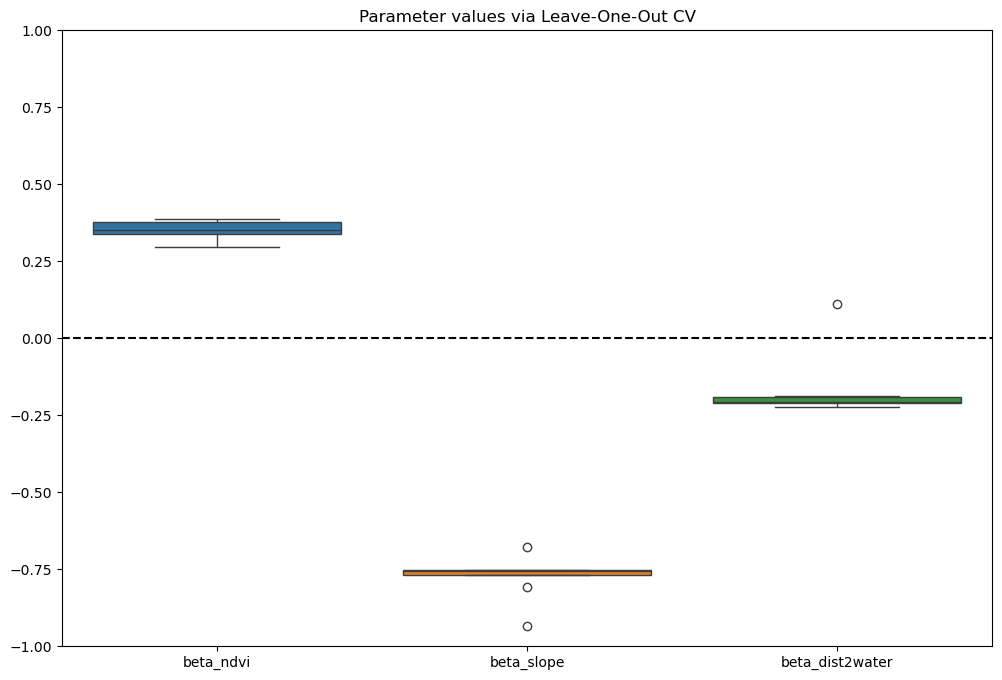

In [99]:
df = params[["heldout_ID", "beta_ndvi", "beta_slope", "beta_dist2water"]]
fig, ax = plt.subplots(figsize = (12, 8))
plt.title("Parameter values via Leave-One-Out CV")
plt.axhline(y = 0, linestyle = "--", color = "black")
sns.boxplot(df)
ax.set_ylim(-1,1)
plt.show()

In [105]:
def plot_boyce_curves_quantile(charts_df, id_col="heldout_ID"):
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(12,7))
    ax.axhline(1.0, linestyle="--", linewidth=1.5)

    for hid, g in charts_df.groupby(id_col):
        g = g.sort_values("q_mid")
        B = g["boyce"].iloc[0] if "boyce" in g.columns else np.nan
        ax.plot(g["q_mid"], g["pe"], linewidth=2, alpha=0.9, label=f"{hid} (B={B:.2f})")

    ax.set_xlabel("Background quantile (0–1)")
    ax.set_ylabel("F-ratio (Predicted / Expected)")
    ax.set_title("Boyce curves by held-out individual (quantile scale)")
    ax.legend(loc="best", fontsize=9)
    plt.tight_layout()
    plt.show()

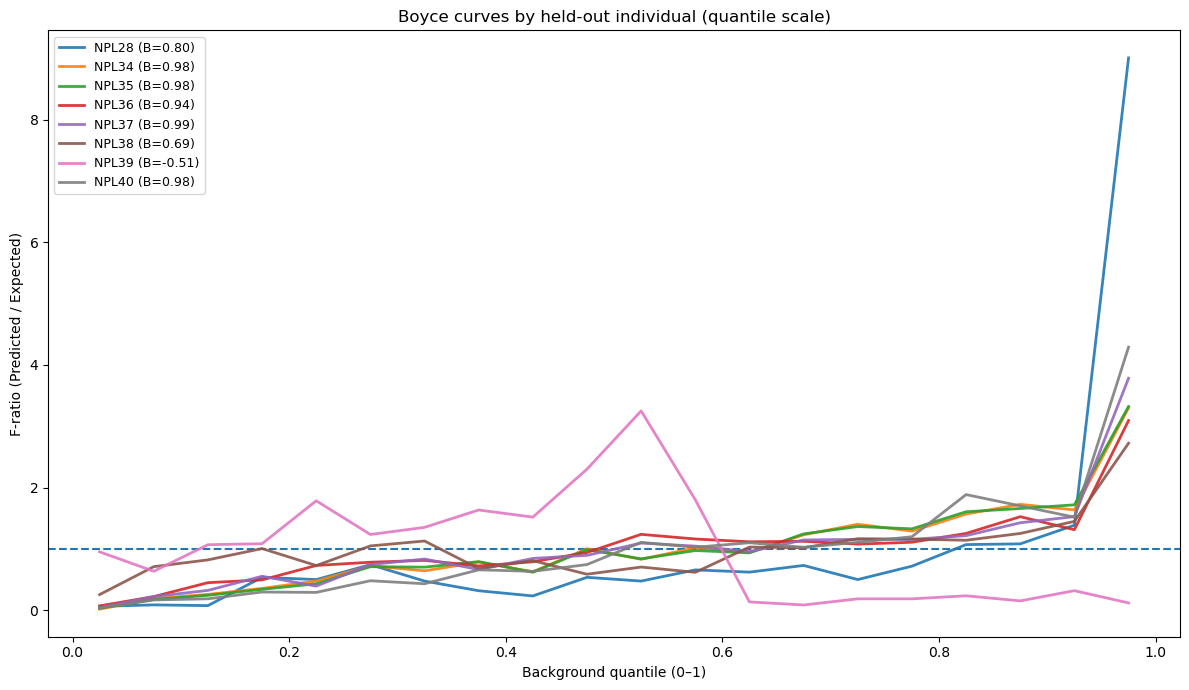

In [109]:
plot_boyce_curves_quantile(charts)